# Phase 5: Model Evaluation and Risk Analysis

Goal:
- Evaluate model performance beyond standard metrics
- Analyze decision thresholds
- Assess calibration of predicted probabilities
- Examine how well models rank borrowers by risk

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_excel("../data/raw/credit_card_clients_raw.xls", header=1)
df = df.rename(columns={"default payment next month": "default_next_month"})
df = df.drop(columns=["ID"])

target_col = "default_next_month"
X = df.drop(columns=[target_col])
y = df[target_col]

OSError: [Errno 22] Invalid argument: 'data\raw\\credit_card_clients_raw.xls'

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
ordinal_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
payment_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
numeric_cols = ["LIMIT_BAL", "AGE"] + bill_cols + payment_cols

log_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("ord", "passthrough", ordinal_cols),
        ("cat", "passthrough", categorical_cols)
    ]
)

log_model = Pipeline([
    ("preprocessing", log_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
log_test_probs = log_model.predict_proba(X_test)[:, 1]

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, log_test_probs)

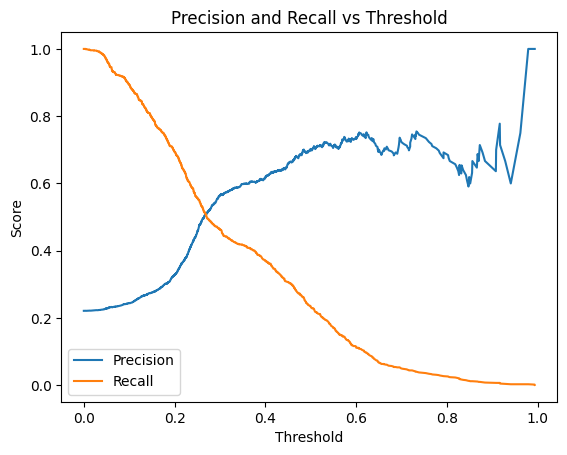

In [ ]:
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.show()

In [ ]:
thresholds_to_test = [0.2, 0.3, 0.4, 0.5]

In [ ]:
for t in thresholds_to_test:
    preds = (log_test_probs >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    
    print(f"\nThreshold: {t}")
    print(cm)


Threshold: 0.2
[[2089 1415]
 [ 305  691]]

Threshold: 0.3
[[3150  354]
 [ 535  461]]

Threshold: 0.4
[[3276  228]
 [ 627  369]]

Threshold: 0.5
[[3405   99]
 [ 764  232]]


Lower thresholds increase recall (detect more defaults) but also increase false positives. Higher thresholds reduce false positives but miss more actual defaults. The choice of threshold depends on business priorities, such as whether missing a default is more costly than incorrectly flagging a borrower.

In [ ]:
log_true, log_pred = calibration_curve(y_test, log_test_probs, n_bins=10)

NameError: name 'calibration_curve' is not defined

In [ ]:
rf_true, rf_pred = calibration_curve(y_test, rf_test_probs, n_bins=10)

In [ ]:
plt.plot(log_pred, log_true, marker='o', label="Logistic")
plt.plot(rf_pred, rf_true, marker='o', label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Comparison")
plt.legend()
plt.show()

Logistic regression is typically better calibrated, meaning its predicted probabilities align more closely with actual default rates. Random forest may achieve higher predictive accuracy but can be less well calibrated without additional techniques.

In [ ]:
df_eval = pd.DataFrame({
    "y_true": y_test,
    "log_prob": log_test_probs,
    "rf_prob": rf_test_probs
})

In [ ]:
df_eval["log_decile"] = pd.qcut(df_eval["log_prob"], 10, labels=False)

NameError: name 'pd' is not defined

In [5]:
log_decile_table = df_eval.groupby("log_decile")["y_true"].mean()
log_decile_table

NameError: name 'df_eval' is not defined

In [6]:
log_decile_table.plot(kind="bar")
plt.title("Default Rate by Decile (Logistic)")
plt.xlabel("Decile (0 = lowest risk)")
plt.ylabel("Default Rate")
plt.show()

NameError: name 'log_decile_table' is not defined

In [7]:
df_eval["rf_decile"] = pd.qcut(df_eval["rf_prob"], 10, labels=False)

rf_decile_table = df_eval.groupby("rf_decile")["y_true"].mean()

rf_decile_table.plot(kind="bar")
plt.title("Default Rate by Decile (Random Forest)")
plt.xlabel("Decile")
plt.ylabel("Default Rate")
plt.show()

NameError: name 'df_eval' is not defined

A strong model should show increasing default rates as decile increases. The top deciles should contain significantly higher default rates than the lower deciles. This indicates the model is effectively ranking borrowers by risk.

In [8]:
threshold = 0.5
log_preds = (log_test_probs >= threshold).astype(int)

false_negatives = df_eval[(y_test == 1) & (log_preds == 0)]
false_negatives.head()

NameError: name 'log_test_probs' is not defined

In [9]:
false_positives = df_eval[(y_test == 0) & (log_preds == 1)]
false_positives.head()

NameError: name 'df_eval' is not defined

False negatives represent borrowers who default but were not flagged by the model, which can lead to financial loss. False positives represent borrowers incorrectly flagged as risky, which may lead to lost business opportunities. The balance between these errors depends on business priorities.

## Final Model Comparison

- Logistic regression:
  - Strong baseline
  - Better calibration
  - Highly interpretable

- Random forest:
  - Captures nonlinear relationships
  - Often improves ranking performance
  - Less interpretable and less calibrated

The preferred model depends on whether interpretability or predictive performance is prioritized.

## Phase 5 Summary

- Threshold selection significantly impacts model performance
- Precision-recall tradeoffs must be considered in imbalanced data
- Logistic regression provides better-calibrated probabilities
- Random forest may improve ranking performance
- Decile analysis shows how effectively the model separates high-risk and low-risk borrowers
- Repayment history remains the dominant predictor of default